In [52]:
import ast

def load_trajectories(txt_path):
    trajectories = {}

    with open(txt_path, "r") as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            # split "ID 1: [(175, 216)]"
            id_part, points_part = line.split(":")

            # extract ID number
            obj_id = int(id_part.replace("ID", "").strip())

            # safely convert string list to Python object
            points = ast.literal_eval(points_part.strip())

            trajectories[obj_id] = points

    return trajectories

In [53]:
TRACK_NUMBER = "282"
TEST_SOURCE = "runs/detect/track"
FOLDER_NAME = f"track_yolo26m_pt_balanced_Cursor_1Class_{TRACK_NUMBER}"
FULL_PATH = TEST_SOURCE + "/" + FOLDER_NAME
trajectories = load_trajectories(f"{FULL_PATH}/trajectories.txt")

In [54]:
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt


def make_Folder(folder_path):
    path = Path(folder_path)
    path.mkdir(parents=True, exist_ok=True)

def draw_trajectories(image_dir, trajectories, output_dir):
    if(not Path(output_dir).exists()):
        make_Folder(output_dir)
    image_paths = sorted(Path(image_dir).glob("*.jpg"))

    colors = {}

    def get_color(obj_id):
        if obj_id not in colors:
            colors[obj_id] = tuple(np.random.randint(0, 255, 3).tolist())
        return colors[obj_id]

    for i, img_path in enumerate(image_paths):
        img = cv2.imread(str(img_path))

        for obj_id, points in trajectories.items():
            color = get_color(obj_id)

            # draw full path up to current frame
            for j in range(1, min(len(points), i+1)):
                pt1 = points[j-1]
                pt2 = points[j]

                cv2.line(img, pt1, pt2, color, 2)

            # draw current point
            if i < len(points):
                cv2.circle(img, points[i], 4, color, -1)

        out_path = Path(output_dir) / img_path.name
        print(f"Saving {out_path}")
        cv2.imwrite(str(out_path), img)


In [55]:
draw_trajectories(
    image_dir=FULL_PATH,
    trajectories=trajectories,
    output_dir=FULL_PATH + "/trajectory_frames"
)

Saving runs\detect\track\track_yolo26m_pt_balanced_Cursor_1Class_282\trajectory_frames\00000.jpg
Saving runs\detect\track\track_yolo26m_pt_balanced_Cursor_1Class_282\trajectory_frames\00001.jpg
Saving runs\detect\track\track_yolo26m_pt_balanced_Cursor_1Class_282\trajectory_frames\00002.jpg
Saving runs\detect\track\track_yolo26m_pt_balanced_Cursor_1Class_282\trajectory_frames\00003.jpg
Saving runs\detect\track\track_yolo26m_pt_balanced_Cursor_1Class_282\trajectory_frames\00004.jpg
Saving runs\detect\track\track_yolo26m_pt_balanced_Cursor_1Class_282\trajectory_frames\00005.jpg
Saving runs\detect\track\track_yolo26m_pt_balanced_Cursor_1Class_282\trajectory_frames\00006.jpg
Saving runs\detect\track\track_yolo26m_pt_balanced_Cursor_1Class_282\trajectory_frames\00007.jpg
Saving runs\detect\track\track_yolo26m_pt_balanced_Cursor_1Class_282\trajectory_frames\00008.jpg
Saving runs\detect\track\track_yolo26m_pt_balanced_Cursor_1Class_282\trajectory_frames\00009.jpg
Saving runs\detect\track\track

In [56]:
def plot_trajectories(trajectories):
    plt.figure()

    for obj_id, points in trajectories.items():
        xs = [p[0] for p in points]
        ys = [p[1] for p in points]
        plt.plot(xs, ys, label=f"ID {obj_id}")

    plt.gca().invert_yaxis()  # image coordinates
    plt.legend()
    plt.title("Animal movement trajectories")
    plt.show()

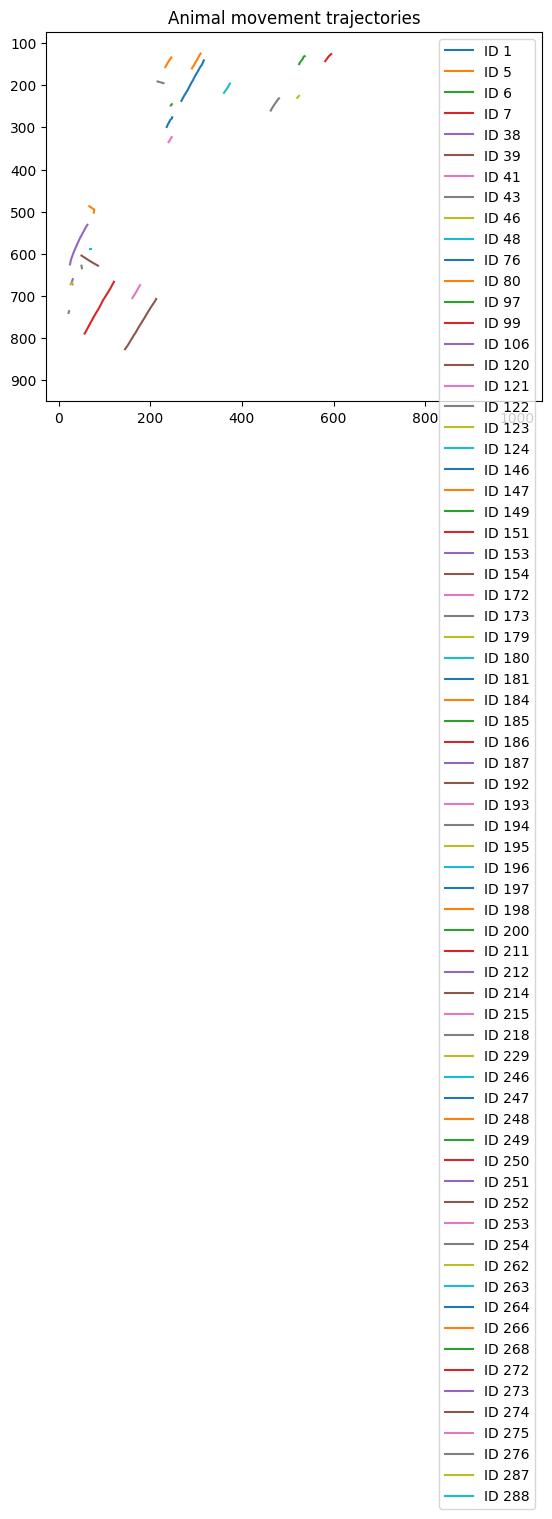

In [57]:
plot_trajectories(trajectories)

In [58]:
import numpy as np
import matplotlib.pyplot as plt


def trajectory_heatmap(trajectories, img_shape):
    heatmap = np.zeros(img_shape[:2])

    for points in trajectories.values():
        for x, y in points:
            if 0 <= x < heatmap.shape[1] and 0 <= y < heatmap.shape[0]:
                heatmap[y, x] += 1

    plt.imshow(heatmap, cmap='hot')
    plt.title("Movement heatmap")
    plt.colorbar()
    plt.show()

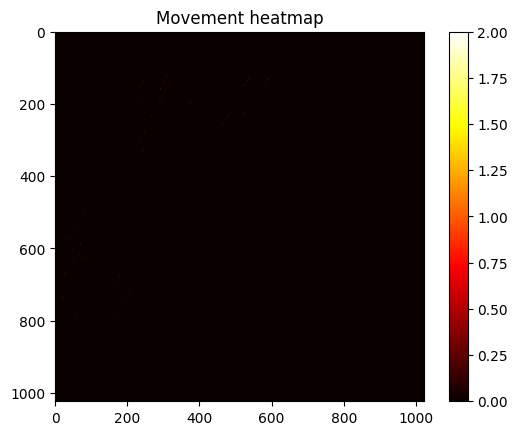

In [59]:
import cv2
from pathlib import Path

img_sample = cv2.imread(str(sorted(Path(FULL_PATH).glob("*.jpg"))[0]))

trajectory_heatmap(
    trajectories=trajectories,
    img_shape=img_sample.shape
)